# Particle Swarm Optimization (PSO)

<a href="https://colab.research.google.com/github/glaucogoncalves/nio/blob/main/lectures/04_03_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Origin and Inspiration

* PSO was proposed by **James Kennedy** and **Russell Eberhart** in 1995 after observing the collective behavior of bird flocks and fish schools, a phenomenon popularized as *swarm intelligence*.  
* The core idea is that each individual (particle) adjusts its movement by balancing **exploration** (global search) and **local exploitation** (social learning).

**Swarm Intelligence**

* PSO pioneered the basic ideas of swarm-intelligence-based computation
* Swarm Intelligence is used also on other algorithms as ant colony algorithms and firefly algorithm 
* PSO is the most widely used swarm-intelligence-based algorithm due to its simplicity and flexibility

## 2. General Structure of PSO

- **Particle**: position vector $\mathbf{x}_i$ that encodes a candidate solution
- **Velocity**: vector $\mathbf{v}_i$ that defines direction and step size of movement
- **Personal history** `pbest` ($\mathbf{x}^*_i$): best position ever visited by the particle
- **Global history** `gbest` ($\mathbf{g}^*$): best position ever found by the swarm
- **Main idea**:
    * At each iteration, the position of each particle is updated
        * The motion goes towards the position of `gbest` and its own best location `pbest`
        * At the same time it has a tendency to move randomly




## 3. Fundamental Equations

The velocity of each particle $i$ at $t\!+\!1$ is given by:

$$
\mathbf{v}_{i}^{t+1} = \mathbf{v}_i^{t} + \alpha\,\varepsilon_1\,(\mathbf{g}^* - \mathbf{x}_i^{t}) +
\beta\,\varepsilon_2\,(\mathbf{x}^*_i - \mathbf{x}_i^{t}) \tag{1}
$$

* $\alpha, \beta$: acceleration coefficients (or *learning factors*).  
* $\varepsilon_1, \varepsilon_2 \sim U(0,1)$: uniform noise vectors.

Next, the position is updated by:

$$
\mathbf{x}_i^{t+1} = \mathbf{x}_i^{t} + \mathbf{v}_i^{t+1} \tag{2}
$$

### Variant with inertia function

$$
\mathbf{v}_{i}^{t+1} = \theta(t)\,\mathbf{v}_i^{t} + \alpha\,\varepsilon_1\,(\mathbf{g}^* - \mathbf{x}_i^{t}) +
\beta\,\varepsilon_2\,(\mathbf{x}^*_i - \mathbf{x}_i^{t}) \tag{3}
$$

The inertia function $\theta(t)$ take values between 0 and 1 and it reduces the velocity, acting as a “virtual mass” that stabilizes the movement of the particles. The simplest function is to use a constant $\theta$, whose value can be set from 0.5 to 0.9. The motion of the particles is more stable and, for this reason, the algorithm is expected to have faster convergence.


<img src="./figures/pso-schema.png" alt="drawing" width="700"/>


*Schematic representation of the motion of a particle in PSO, moving toward the global best* $\mathbf{g}^*$ *and the current personal best* $\mathbf{x}^*_i$ *for each particle* $i$.

## 4. Classical Pseudocode

1. Initialize a population of $n$ particles (positions $\mathbf{x}_i$ and velocities $\mathbf{v}_i$)  
2. Evaluate $f(\mathbf{x}_i)$ and set $\mathbf{x}^*_i = \mathbf{x}_i$  
3. Set $\mathbf{g}^* = \arg\min f(\mathbf{x}^*_i)$  
4. While stopping criterion is not satisfied:  
    - For each particle $i$:  
        - Update $\mathbf{v}_i$ using Eq. (1) or (3)  
        - Update $\mathbf{x}_i = \mathbf{x}_i + \mathbf{v}_i$  
        - Evaluate $f(\mathbf{x}_i)$  
        - If $f(\mathbf{x}_i) < f(\mathbf{x}^*_i)$:  
            - $\mathbf{x}^*_i = \mathbf{x}_i$  
    - Update $\mathbf{g}^* \text{ with the best } \mathbf{x}^*_i$


5. Return $\mathbf{g}^*$


## Practical Execution Example


### 1 — Functions Used

#### 📌 Rosenbrock

**Definition:**

$$
f(x_1, x_2) = 100\,(x_2 - x_1^2)^2 + (1 - x_1)^2
$$

**Global minimum:**  
$(1, 1)$ with $f_{\min} = 0$

**Characteristics:**  
Smooth landscape, but with a **narrow and curved valley**. Requires good exploration to find the valley and precise movement to follow it.

---

#### 📌 Ackley

**Definition:**

$$
f(x) = -20\,e^{-0.2\sqrt{\frac{x_1^2 + x_2^2}{2}}}
- e^{\frac{\cos(2\pi x_1) + \cos(2\pi x_2)}{2}}
+ 20 + e
$$

**Global minimum:**  
$(0, 0)$ with $f_{\min} = 0$

**Characteristics:**  
Highly **multimodal**: many concentric local minima. Ideal for testing whether the algorithm avoids getting trapped and converges to the global minimum.

---

The GIFs illustrate, frame by frame, the trajectory of the particles and the convergence curve of PSO over these two surfaces.

**Note: the GIF cannot be displayed on GitHub. Open the Colab notebook to visualize the behavior of both functions.**


https://github.com/glaucogoncalves/nio/blob/main/lectures/04_03_Particle_Swarm_Colab.ipynb


<img src="https://raw.githubusercontent.com/KeishiIshihara/pso_with_python/2072c5aac9910d31043c718d6521f92d7d8a0111/gif/PSO_Rosenbrock_population_30.gif" width="1800">


<img src="https://raw.githubusercontent.com/KeishiIshihara/pso_with_python/2072c5aac9910d31043c718d6521f92d7d8a0111/gif/PSO_Ackley_population_30.gif" width="1800">


## Binary PSO (BPSO)

* The standard PSO take continuous values (position and velocity).
* What to do when decision variables are binary?
* [(Kennedy & Eberhart, 1997)](https://ieeexplore.ieee.org/abstract/document/637339) proposed a stochastic approach to discretize PSO
  * The velocity is adjusted to be between 0 and 1, and it is interpreted as a probability

### Strategy

1. Before computing $\mathbf{x}_i$, <u>each component</u> of the continuous velocity $\mathbf{v}_i = (v_{i1} , v_{i2} , \ldots , v_{ik} , \ldots , v_{id} )$ is transformed using a sigmoid transformation

$S(v_{ik}) = \frac{1}{1+e^{-v_{ik}}}, \, k = 1,2,\ldots,d$

2. A uniformly distributed random number $r \in (0, 1)$ is drawn and the position is set as

$x_{ik} =
      \begin{cases}
      1  & \text{if } r \lt S(v_{ik}) \\
      0 & \text{otherwise}
      \end{cases} \\ $

# PSO Implementation


## Rosenbrock Function


In [20]:
import numpy as np

# -------- Rosenbrock Function --------
def rosenbrock(x):
    return 100.0 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

# ---------- PSO Algorithm ----------
def pso(func, bounds, n_particles=30, n_iter=100,
        w=0.7, c1=1.5, c2=1.5, vmax=0.2):
    dim = len(bounds)

    # initial positions and velocities
    pos = np.random.uniform(bounds[:, 0], bounds[:, 1],
                            size=(n_particles, dim))
    vel = np.random.uniform(-abs(bounds[:, 1] - bounds[:, 0]),
                            abs(bounds[:, 1] - bounds[:, 0]),
                            size=(n_particles, dim)) * 0.1

    pbest = pos.copy()
    pbest_val = np.apply_along_axis(func, 1, pbest)
    gbest_idx = np.argmin(pbest_val)
    gbest = pbest[gbest_idx].copy()
    gbest_val = pbest_val[gbest_idx]

    hist = [gbest_val]

    for _ in range(n_iter):
        r1, r2 = np.random.rand(n_particles, dim), np.random.rand(n_particles, dim)
        # velocity update
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -vmax, vmax)

        # position update
        pos += vel
        pos = np.clip(pos, bounds[:, 0], bounds[:, 1])

        # evaluation
        vals = np.apply_along_axis(func, 1, pos)
        better = vals < pbest_val
        pbest[better] = pos[better]
        pbest_val[better] = vals[better]

        # new gbest
        gbest_idx = np.argmin(pbest_val)
        if pbest_val[gbest_idx] < gbest_val:
            gbest_val = pbest_val[gbest_idx]
            gbest = pbest[gbest_idx].copy()

        hist.append(gbest_val)

    return gbest, gbest_val, np.array(hist)

# -------- Execution on Rosenbrock --------
bounds_rb = np.array([[-5, 5], [-5, 5]])

gbest, gbest_val, hist = pso(rosenbrock, bounds_rb,
                             n_particles=30, n_iter=100)

print("Rosenbrock  —  best x:", gbest, "|  f(x) =", gbest_val)

Rosenbrock  —  best x: [0.99880331 0.99747418] |  f(x) = 3.2243169269128546e-06


## Ackley Function

In [21]:
import numpy as np

# -------- Ackley Function --------
def ackley(x):
    d = len(x)
    term1 = -20.0 * np.exp(-0.2 * np.sqrt((x[0]**2 + x[1]**2) / d))
    term2 = -np.exp((np.cos(2*np.pi*x[0]) + np.cos(2*np.pi*x[1])) / d)
    return term1 + term2 + 20 + np.e

# Reuse the same pso() function defined earlier

# -------- Execution on Ackley --------
bounds_ak = np.array([[-5, 5], [-5, 5]])

gbest, gbest_val, hist = pso(ackley, bounds_ak,
                             n_particles=30, n_iter=100)

print("Ackley  —  best x:", gbest, "|  f(x) =", gbest_val)

Ackley  —  best x: [-7.34691555e-08 -6.37151000e-08] |  f(x) = 2.7506142119548826e-07


# Using the pyMetaheuristic Library


In [22]:
!pip install pyMetaheuristic


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Rosenbrock Function


In [ ]:
import numpy as np
import pymetaheuristic
import matplotlib.pyplot as plt

# ----- Objective Function -----
def rosenbrock(variables_values = [0, 0]):
    x1, x2 = variables_values
    return 100*(x2 - x1**2)**2 + (1 - x1)**2

# PSO parameters
iterations     = 100
min_values = [-5,-5]   # lower bound
max_values = [5,5]   # upper bound

parameters_rb = {
    'swarm_size'  : 30,
    'decay'       : 1,
    'w'           : 0.7,
    'c1'          : 1.5,
    'c2'          : 1.5,
}

# Run the PSO
result = pymetaheuristic.optimize(
					algorithm                  = "ga",
                    config				       = parameters_rb,
					target_function            = rosenbrock,
					min_values                 = min_values,
					max_values                 = max_values,
					max_steps                  = iterations,
					store_history              = True,
                    seed                       = 42
				)

print("Running with the same parameters of the from scratch version")
print("Library PSO → x* =", np.round(result.best_position,4), " f* =", round(result.best_fitness,8))

Running with the same parameters of the from scratch version
Library PSO → x* = [1.0004 1.0009]  f* = 1.9e-07


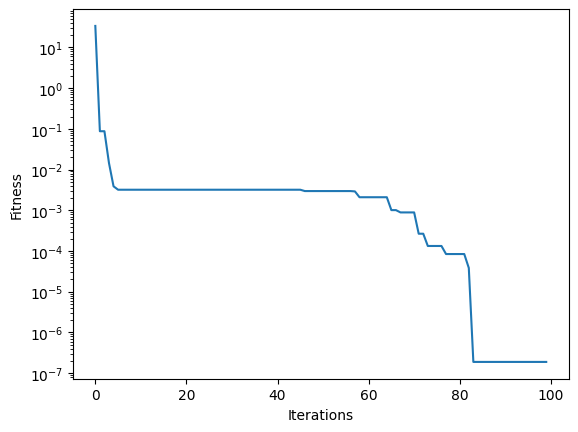

In [24]:
best_m = []
for r in result.history:
    best_m.append(r['best_fitness'])

plt.plot(best_m,)
plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.yscale("log")
plt.show()

## Ackley Function

In [ ]:
import numpy as np
import pymetaheuristic

# ----- Objective Function -----
def ackley(variables_values = [0, 0]):
    x1, x2 = variables_values
    term1  = -20.0 * np.exp(-0.2 * np.sqrt((x1**2 + x2**2) / 2))
    term2  = -np.exp((np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2)) / 2)
    return term1 + term2 + 20 + np.e

# PSO parameters
iterations     = 100
min_values = [-5,-5]   # lower bound
max_values = [5,5]   # upper bound

parameters_ak = {
    'swarm_size'  : 30,
    'decay'       : 1,
    'w'           : 0.7,
    'c1'          : 1.5,
    'c2'          : 1.5,
}

# Run the PSO
result = pymetaheuristic.optimize(
					algorithm                  = "ga",
                    config				       = parameters_rb,
					target_function            = rosenbrock,
					min_values                 = min_values,
					max_values                 = max_values,
					max_steps                  = iterations,
					store_history              = True,
                    seed                       = 42
				)

print("Running with the same parameters of the from scratch version")
print("Library PSO → x* =", np.round(result.best_position,4), " f* =", round(result.best_fitness,8))

Running with the same parameters of the from scratch version
Library PSO → x* = [1.0004 1.0009]  f* = 1.9e-07


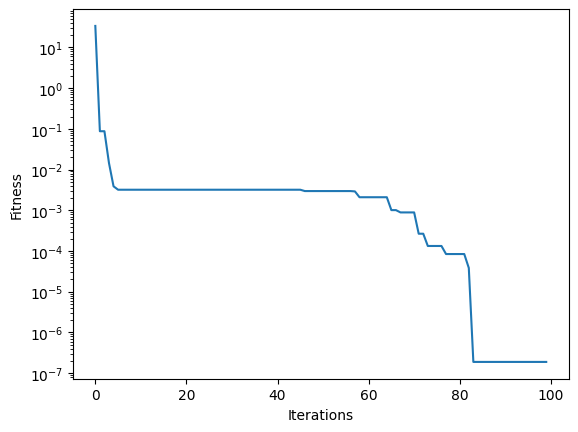

In [26]:
best_m = []
for r in result.history:
    best_m.append(r['best_fitness'])

plt.plot(best_m,)
plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.yscale("log")
plt.show()